In [1]:
# 2025.11.10.월 8교시 머신러닝 5 장 - 회귀 (설명력!!!!) => Deep Learning과 연결되니 신경쓰자!!
# 학습 목표
# • 개념 이해: 선형 회귀의 기본 원리, 비용 함수, 경사 하강법을 이해하고 릿지, 라쏘 등 정규화 회귀의 필요성과 종류를 학습
# • 실습 능력 향상: Scikit-learn 라이브러리를 활용하여 다양한 회귀 모델을 직접 구축하고, 데이터를 분석하며 모델의 성능을 평가하고 개선하는 능력을 배양.
# • 모델 평가 및 개선: MSE, RMSE, R²(R 스퀘어 - 설명력) 등 회귀 모델의 성능 평가 지표를 이해하고, 
#                      과적합 문제를 해결하기 위한 데이터 전처리, 하이퍼파라미터 튜닝, 앙상블 기법을 학습

In [ ]:
# 2025.11.11.화 1교시

### 📌 용어 설명
#### L1, L2 규제에서 'L'의 의미
**'L'**은 **"Lp norm" (르베그 공간 노름, Lebesgue space norm)**의 약자이며, 벡터의 크기나 길이를 측정하는 수학적 개념인 **노름(Norm)**을 의미합니다.

| 규제 방법 | 설명 | 효과 |
|:--------:|------|------|
| **L1 규제**<br>(Lasso 회귀) | 손실 함수에 가중치의 **절댓값의 합**(L1 노름)을 페널티로 추가 | 특정 가중치를 0으로 만들어 **특성 선택**(feature selection) 효과 |
| **L2 규제**<br>(Ridge 회귀) | 손실 함수에 가중치의 **제곱의 합**(L2 노름, 유클리드 노름)을 페널티로 추가 | 가중치를 전반적으로 작게 만들어 **과적합 방지** |

> 💡 **요약:** 'L'은 노름의 종류를 나타내며, 숫자 1과 2는 각각 1-노름과 2-노름을 의미합니다.

---

#### R²(결정계수)에서 'R'의 의미

**'R'**은 영어 단어 **'Regression'**(회귀) 또는 **'Correlation'**(상관관계)에서 유래했습니다.

**R²의 역할:**
- 회귀 모델이 데이터의 변동성을 얼마나 잘 설명하는지를 나타내는 지표
- 독립 변수가 종속 변수를 얼마나 잘 예측하는지 측정

**수학적 의미:**
- 단순 선형 회귀(독립 변수 1개)에서 R² = **(상관계수 r)²**
- 이러한 수학적 관계 때문에 'R²'라는 표기가 사용됨

> 💡 **요약:** R



### 🔁 역행렬이란?
- **역행렬(inverse matrix)**은 어떤 정방행렬 \( A \)에 대해, 행렬 \( A^{-1} \)이 존재하여 다음 조건을 만족하는 행렬을 말합니다:

$$
A \cdot A^{-1} = A^{-1} \cdot A = I
$$

여기서 $I$는 단위행렬(identity matrix)입니다.

- 역행렬은 **행렬의 나눗셈** 개념과 유사하며, 선형 방정식 \( Ax = b \)를 풀 때 \( x = A^{-1}b \)로 표현할 수 있어요.

---
### 🚫 역행렬이 존재하지 않는 2가지 경우

역행렬은 **모든 행렬에 대해 존재하지 않습니다.** 다음은 역행렬이 존재하지 않는 대표적인 두 가지 경우입니다:

1. **행렬이 정방행렬이 아닐 때 (비정방행렬)**
   - 역행렬은 **정방행렬(square matrix)**, 즉 행과 열의 수가 같은 행렬에서만 정의됩니다.
   - 예: \( 2 $\times$ 3 \) 또는 \( 3 $\times$ 2 \) 행렬은 역행렬을 가질 수 없습니다.

2. **행렬식(determinant)이 0일 때**
   - 정방행렬이라도 **행렬식이 0이면 역행렬이 존재하지 않습니다.**
   - 이런 행렬을 **특이행렬(singular matrix)**이라고 부릅니다.
   - 이는 행렬이 **선형종속**일 때 발생하며, 열 또는 행 중 일부가 다른 열/행의 선형결합일 경우입니다.


- 공분산(행렬)
- 공분산을 분해(decompose) => 고유값, 고유벡터(직선이다, 분산이 제일 큰 곳이고 이걸 사형(투영)하면 PCA가 나온다)가 

공분산과 행렬은 통계학과 머신러닝에서 매우 밀접하게 연결되어 있어요. 특히 **다변량 데이터(multivariate data)**를 다룰 때 공분산을 **행렬 형태**로 표현하면 훨씬 더 강력하고 직관적인 분석이 가능합니다.
---
### 📌 공분산이란?

- 공분산은 **두 변수 간의 선형 관계**를 나타내는 값입니다.
- 두 변수 X 와  Y 의 공분산은 다음과 같이 정의됩니다:

$$ \text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y}) $$

- 양수 → 함께 증가하는 경향  
- 음수 → 한쪽이 증가할 때 다른 쪽은 감소  
- 0 → 선형 관계 없음

---

### 🧮 공분산 행렬(Covariance Matrix)

- 여러 변수 간의 공분산을 **행렬 형태**로 정리한 것이 **공분산 행렬**입니다.
- 예를 들어, 세 변수 $$X_1, X_2, X_3 $$가 있다면 공분산 행렬은 다음과 같습니다:

$$
\Sigma =
\begin{bmatrix}
\text{Cov}(X_1, X_1) & \text{Cov}(X_1, X_2) & \text{Cov}(X_1, X_3) \\
\text{Cov}(X_2, X_1) & \text{Cov}(X_2, X_2) & \text{Cov}(X_2, X_3) \\
\text{Cov}(X_3, X_1) & \text{Cov}(X_3, X_2) & \text{Cov}(X_3, X_3)
\end{bmatrix}
$$

- **대칭 행렬**이며, 대각선은 각 변수의 **분산**입니다.

---

### 📊 왜 중요한가요?

- **PCA(주성분 분석)**: 공분산 행렬의 고유값 분해를 통해 차원 축소 수행
- **다변량 정규분포**: 공분산 행렬이 분포의 형태를 결정
- **머신러닝**: 특성 간 상관관계를 파악하거나 이상치 탐지 등에 활용


In [3]:
# LinearRegression 클래스 - Ordinary Least Squares (OLS)
# LinearRegression 클래스는 예측값과 실제 값의 RSS(Residual Sum of Squares)를 최소화해 OLS(Ordinary Least Squares) 추정 방식으로 구현한 클래스입니다. 
# LinearRegression 클래스는 fit() 메서드로 X, y 배열을 입력받으면 회귀 계수(Coefficients)인 W를 coef_ 속성에 저장합니다.

# Ordinary Least Squares 기반의 회귀 계수 계산은 **입력 피처의 독립성에 많은 영향**을 받습니다. 
# 피처 간의 상관관계가 매우 높은 경우 분산이 매우 커져서 오류에 매우 민감해집니다. 
# 이러한 현상을 다중 공선성(multi-collinearity) 문제라고 합니다. 

# 일반적으로 상관관계가 높은 피처가 많은 경우 독립 적인 중요한 피처만 남기고 제거하거나 규제를 적용합니다. 
# 또한 매우 많은 피처가 다중 공선성 문제를 가지고 있다면 PCA를 통해 차원 축소를 수행하는 것도 고려해 볼 수 있습니다. 
# 다음으로 예측된 회귀 모델을 평가하는 방법에 대해 알아보겠습니다.

#### 오차를 구하는 함수!!! : 회귀의 성능을 평가하는 지표: 

| 평가 지표 | 설명 | 수식 |
|---------|------|------|
| **MAE** | Mean Absolute Error(MAE)이며 실제 값과 예측값의 차이를 절댓값으로 변환해 평균한 것. | $MAE = \frac{1}{n}\sum_{i=1}^{n}\|Y_i - \hat{Y_i}\|$ |
| **MSE** | Mean Squared Error(MSE)이며 실제 값과 예측값의 차이를 제곱해 평균한 것. | $MSE = \frac{1}{n}\sum_{i=1}^{n}(Y_i - \hat{Y_i})^2$ |
| **RMSE** | MSE 값은 오류의 제곱을 구하므로 실제 오류 평균보다 더 커지는 특성이 있으므로<br> MSE에 루트를 씌운 것이 RMSE(Root Mean Squared Error) | $RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(Y_i - \hat{Y_i})^2}$ |
| **R²** | 분산 기반으로 예측 성능을 평가합니다. <br>실제 값의 분산 대비 예측값의 분산 비율을 지표로 하며, **1에 가까울수록 예측 설명력 높다**(not 정확도). | $R^2 = \frac{예측값\ Variance}{실제값\ Variance}$ |

> 이 밖에 MSE나 RMSE에 로그를 적용한 MSLE(Mean Squared Log Error)와 RMSLE(Root Mean Squared Log Error)도 사용.

- E : Error , 제곱근이나 절대값을 하는 이유는 음수를 제거하기 위함이다
- R2 : R squere , 분산 (Variance = 정보, 정보량!!!! : 평균으로부터 퍼져 있는 정도)
<br><br>

| 평가 방법 | 사이킷런 평가 지표 API(함수) | Scoring 함수 적용 값 |
|---------|---------------------|-------------------|
| **MAE** | metrics.mean_absolute_error | 'neg_mean_absolute_error' |
| **MSE** | metrics.mean_squared_error | 'neg_mean_squared_error' |
| **RMSE** | metrics.mean_squared_error를 그대로 사용하되<br>squared 파라미터를 False로 설정 | 'neg_root_mean_squared_error' |
| **MSLE** | metrics.mean_squared_log_error | 'neg_mean_squared_log_error' |
| **R²** | metrics.r2_score | 'r2' |

In [ ]:
# chap05에 boston_house_prices.csv 파일 옮겨놓기 (20251111-수업내용 폴더에서 다운로드 후 )

### 05 다항 회귀와 과(대)적합/과소적합 이해
n = 독립변수 개수, 피쳐수(Features), 
#### 다항 회귀 이해
지금까지 설명한 회귀는  $y = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n$ ,과 같이 독립변수(feature)와 종속변
수(target)의 관계가 일차 방정식 형태로 표현된 회귀였습니다.  
하지만 세상의 모든 관계를 직선으로만 표현할 수는 없습니다.  
회귀가 독립변수의 단항식이 아닌 2차, 3차 방정식과 같은 다항식으로 표현되는 것을 다항(Polynomial) 회귀라고 합니다.  다항 회귀 모델은 $y = w_0 + w_1x_1 + w_2x_2 + w_3x_2 + w_4x^2 + w_5x^2$ 과 같이 표현할 수 있습니다.  \
다항회귀도 **선형 회귀** 다. 다항은 w가 여러개인거다! x가 아니라~ x가 여러개는 피쳐 갯수가 많아진거다.\
즉 다항 회귀는 **피쳐수를 늘리는 거**다


#### 다항 회귀를 이용한 과소적합 및 과적합 이해
다항식의 차수가 높아질수록 매우 복잡한 피처 간의 관계까지 모델링이 가능합니다.\
하지만 다항 회귀의 차수(degree)를 높일수록 학습 데이터에만 너무 맞춘 학습이 이뤄져서 정작 테스트 데이터 환경에서는 오히려 예측 정확도가 떨어집니다. \
즉, 차수가 높아질수록 과적합의 문제가 크게 발생합니다.

$$ 비용 함수 목표 = Min (RSS (W) + alpha * ||W||^2 ) $$

여기서 alpha는 학습 데이터 적합 정도와 회귀 계수 값의 크기 제어를 수행하는 튜닝 파라미터입니다.  
  
비용 함수의 목표가 (RSS (W) + alpha * | W)를 최소화하는 W 벡터를 찾는 것일 때 alpha가 어떤 역할을 하는지 살펴보겠습니다.   
alpha가 0(또는 매우 작은 값)이라면 비용 함수 식은 기존과 동일한 Min (RSS(W) + 0)이 될 것입니다.   
  
반면에 alpha가 무한대(또는 매우 큰 값라면 비용 함수 식은 RSS(W)에 비해 alpha * WB 값이  
너무 커지게 되므로 W 값을 0(또는 매우 작게)으로 만들어야 Cost가 최소화되는 비용 함수 목표를 달성할 수 있습니다.  
즉, alpha 값을 크게 하면 비용 함수는 회귀 계수 W의 값을 작게 해 과적합을 개선할 수 있으며   
alpha 값을 작게 하면 회귀 계수 W의 값이 커져도 어느 정도 상쇄가 가능하므로 학습 데이터 적합을 더 개선할 수 있습니다.  

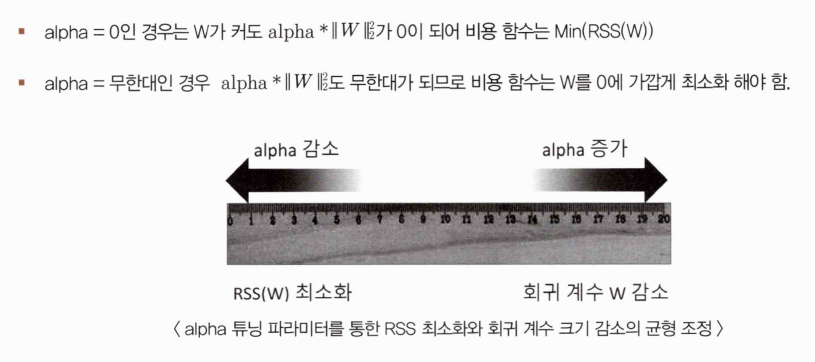  

alpha를 0에서부터 지속적으로 값을 증가시키면 회귀 계수 값의 크기를 감소시킬 수 있습니다.  
이처럼 비용 함수에 alpha 값으로 페널티를 부여해 회귀 계수 값의 크기를 감소시켜 과적합을 
개선하는 방식을 규제(Regularization)라고 부릅니다. 규제는 크게 12 방식과 L1 방식으로 구분됩니다.  
L2 규제는 위에서 설명한 바와 같이 alpha *|| W B와 같이 W의 제곱에 대해 페널티를 부여하는 방식을 말합니다.  
L2 규제를 적용한 회귀를 릿지(Ridge) 회귀라고 합니다.  

라쏘(Lasso) 회귀는 11 규제를 적용한 회귀입니다.  
L1 규제는 alpha * || W |와 같이 W의 절댓값에 대해 페널티를 부여합니다.  
L1 규제를 적용하면 영향력이 크지 않은 회귀 계수 값을 0으로 변환합니다.  


### 5. 정규화 회귀 (Regularized Regression)
과적합을 방지하는 가장 효과적인 방법 중 하나는 정규화(Regularization)입니다.  
정규화는 회귀 계수(w)의 크기가 너무 커지지 않도록 비용 함수에 패널티 항을 추가하는 기법입니다.  
회귀 계수가 크다는 것은 모델이 특정 피처에 너무 의존하여 복잡해졌다는 신호일 수 있기 때문입니다.  

비용 함수 = RSS(W) + alpha * (회귀 계수(W) 크기에 대한 패널티)  

여기서 alpha 는 정규화의 강도를 조절하는 하이퍼파라미터입니다.  
• alpha 가 크면: 패널티가 강해져 회귀 계수들이 0 에 가까워집니다. ~~모델이 단순해지고 분산이 줄어들지만, 편향이 커질 수 있다.~~  
• alpha 가 작으면: 패널티가 약해져 일반적인 선형 회귀(OLS)와 유사해집니다.


### 5.1. 릿지 회귀 (Ridge Regression)
릿지 회귀는 L2 정규화를 사용하는 회귀 모델입니다. 패널티 항으로 회귀 계수의 제곱합을 사용합니다.  
비용 함수(Ridge) = RSS(W) + alpha * Σ(wᵢ)²
릿지 회귀는 회귀 계수의 크기를 전반적으로 줄여주지만, 0 으로 만들지는 않습니다.  
따라서 모든 피처를 모델에 유지하면서 과적합을 방지하는 데 효과적입니다.  
특히 피처 간 상관관계가 높은 **다중공선성(Multicollinearity)** 문제 해결에 유용합니다.

### 라쏘 회귀
W의 절댓값에 페널티를 부여하는 11 규제를 선형 회귀에 적용한 것이 라쏘(Lasso) 회귀입니다.  
즉 1규제는 alpha * | W |를 의미하며, 라쏘 회귀 비용함수의 목표는 RSS(W) + alpha * | W | 식을 최소화하는 W를 찾는 것입니다.  
L2 규제가 회귀 계수의 크기를 감소시키는 데 반해, L1 규제는 불필요한 회귀 계수를 급격하게 감소시켜 0으로 만들고 제거합니다.  
이러한 측면에서 11 규제는 적절한 피처만 회귀에 포함시키는 피처 선택의 특성을 가지고 있습니다. => **Feature Selection**


### 07 로지스틱 회귀
로지스틱 회귀는 선형 회귀 방식을 **분류**에 적용한 알고리즘입니다.  
즉, 로지스틱 회귀는 분류에 사용됩니다.  로지스틱 회귀 역시 선형 회귀 계열입니다.  
회귀가 선형인가 비선형인가는 독립변수가 아닌 가중치(weight) 변수가 선형인지 아닌지를 따릅니다.  
로지스틱 회귀가 선형 회귀와 다른 점은 학습을 통해 선형 함수의 회귀 최적선을 찾는 것이 아니라  
시그모이드(Sigmoid) 함수 최적선을 찾고 이 시그모이드 함수의 반환 값을 ~~확률~~ "**우도**"로 간주해 ~~확률~~ "우도"에 따라 분류를 결정한다는 것이다.  
=> 크로스 엔트로피함수 0.5 기준으로 0, 1 판단(분류)

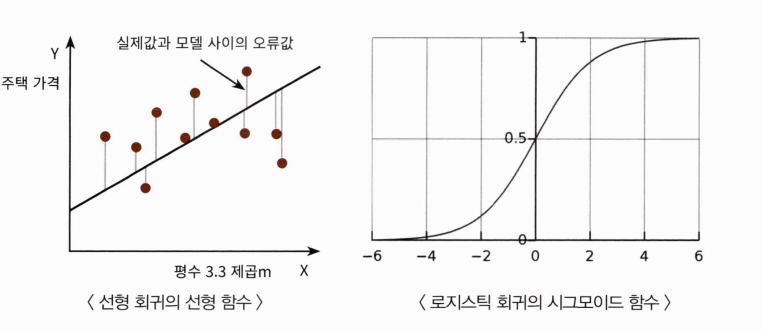 
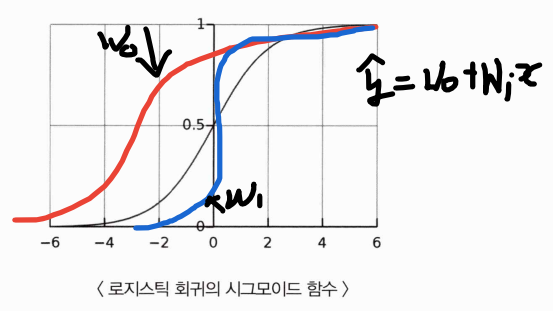

W 찾기 : 우도(likelihood)

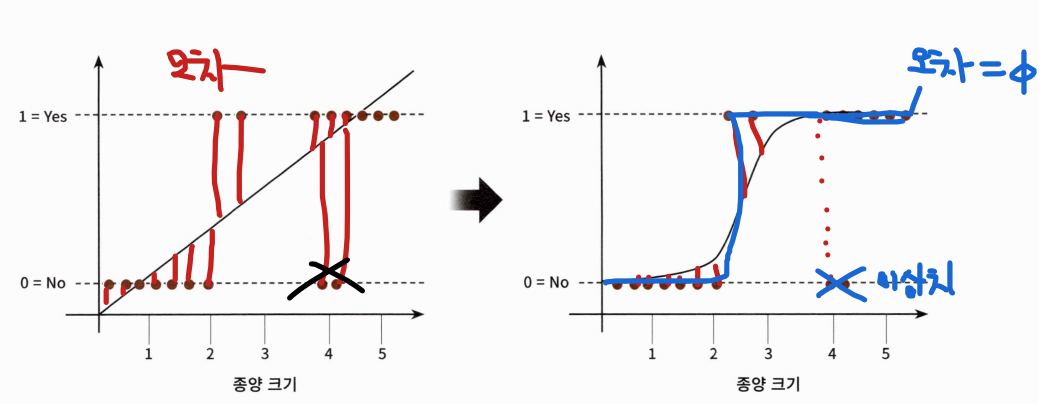  
* 시그모이드 함수를 쓰면 오차를 줄일 수 있다~~~아